# Revisions- Figure 3-7 + Supplementary Figure 1+2 Code
Contains code to produce figures present in Fig 3-7. 
#### Run Order
- Environment and Imports
- Config (paths, parameters)
- Load Data
- Process Data
- Cross condition decoding generalization (CCG) figures:
    - Figure 3: B
    - Figure 4: B
- CCG Class predictions:
    - Figure 3: C
    - Figure 4: C, F
- Linear SVM accuracy figures:
    - Figure 5: C, D
    - Figure 6: C, D
    - Figure 7: C, G
    - Supplementary Figure 2: F, H
- Save Figures and Tables

## Setup


#### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# Environment & Imports Setup
import matplotlib as matplotlib
%matplotlib inline 

#code ocean step
use_code_ocean = False
if use_code_ocean:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import pandas as pd
import random
from datetime import datetime
from itertools import product

print(f"matplotlib {matplotlib.__version__} | Seaborn {sns.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) # pd.set_option('future.no_silent_downcasting', True)
np.random.seed(1) #set seed for reproducibility 
random.seed(1)
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
here = info["repo_root"]
print(f" Here: {here}")
_plot_posthoc_src = os.path.join(here, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)

#custom function import
from preprocess_data import hyper_param_dict, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import save_fig_in_main_fig_dir,  save_plot_record_as_csv_txt, make_folder
from ax_modifier_functions import add_spaces_linebreak_to_stage_ticks, set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
##Set/create save and load folder paths 
results_location = Path(here).parents[0] / "results"
data_location = Path(here).parents[0] / "data"
make_folder(results_location)
make_folder(data_location)
print(f"Saving results in {results_location}. Data location is {data_location}")
csv_folder_most_recent = results_location/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder(csv_folder_most_recent)

matplotlib 3.8.4 | Seaborn 0.12.1
Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results' already exists.
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data' already exists.
Saving results in c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


<Figure size 960x720 with 0 Axes>

#### Extract pre-built time-series and transform


In [3]:
def get_matrix_of_run_record(latest_runs: pd.DataFrame,
                              decoding_type_to_var: dict,
                                col_to_extract: str = 'weight_file_saved'):
    ''' read in the latest runs of decoding and return a dictionary of dataframes for each decoding type 
    inputs:
    latest_run: dataframe of latest runs with columns including 'decoding_type' and e.g. activity matrix or cell weights
    decoding_type_to_var: dict mapping decoding_type strings to variable names for the output dictionary '''

    # read parquets into a dictionary
    run_record_df = {}
    for _, row in latest_runs.iterrows():
        decoding_type = row['decoding_type']
        extracted_filepath = row[col_to_extract]
        print(f"extracted filepath in {col_to_extract}: {extracted_filepath}")
        if decoding_type in decoding_type_to_var:
            var_name = decoding_type_to_var[decoding_type]
            run_record_df[var_name] = pd.read_parquet(extracted_filepath)
            run_record_df[var_name]['run_end_time'] = row['run_end_time']
            run_record_df[var_name]['run_source_dataset'] = row['run_dataset_used']
            run_record_df[var_name]['run_end_date'] = run_record_df[var_name]['run_end_time'].astype(str).str.split(" ").str[0]
            run_record_df[var_name]['dataset_label'] = ("Old Paper Ensembles" if r"\data\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet" in row['run_dataset_used'] else "New Ensembles")
            print(f"Loaded {decoding_type} from {row['run_end_time']} ({len(run_record_df[var_name])} rows) -> {var_name}")
        else:
            print(f"Warning: Unknown decoding type '{decoding_type}', skipped")
    return run_record_df

def parse_decoder_key(df, stage_names, geno_order, decoder_key_col='decoder_key'):
    """
    Parse decoder_key column to extract bootstrap_run, ensemble, geno_day, k_fold, train_on, and test_on.
    
    Parameters----------
    df : pd.DataFrame containing the decoder_key column
    stage_names : list of stage/ensemble names to match (e.g., ['early', 'late'])
    geno_order : list of genotype-day values to match (e.g., ['HET_D1', 'WT_D1'])
    decoder_key_col : str, optional
        Name of the decoder key column (default: 'decoder_key')

    Returns-------
    pd.DataFrame with added columns: bootstrap_run, ensemble, geno_day, k_fold, train_test_info, train_on, test_on
    """
    result = df.copy()
    key_col = result[decoder_key_col]
    
    result['bootstrap_run'] = key_col.str.split('_').str[0].astype(int)
    result['ensemble'] = key_col.str.extract(f"({'|'.join(stage_names)})")
    result['geno_day'] = key_col.str.extract(f"({'|'.join(geno_order)})")
    result['k_fold'] = key_col.str.split('_').str[-1].astype(int)
    
    result['train_test_info'] = result.apply(
        lambda r: r[decoder_key_col].split(r['geno_day'] + '_', 1)[-1], axis=1)
    result['train_on'] = result['train_test_info'].str.split('_to_').str[0]
    result['test_on'] = result['train_test_info'].str.split('_to_').str[1].str[:-2]
    
    return result

In [4]:
#declare loc/names of files to read
trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet" # new matlab made 10k shuffle file 
# trial_df_filename = data_location /  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)


In [5]:
#set what dataset to use, therefore waht col names are improtant 
use_new_dataset = True
if use_new_dataset:
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else:   
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
stage_col = 'task_phase_vec'
## 
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
# get trial summary info
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = 'subject_name')#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')[unit_ID_col].nunique()

#get processed dataset 
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)
subject_stage_info_df.sample()

,subject_name,geno_day,task_phase_vec,neuron_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
174,7_6_HET_RS2,Het CLNZ,Early_IA_Error,"[7_6_HET_RS2-10, 7_6_HET_RS2-20, 7_6_HET_RS2-2...",12,107,"[2, 3, 5]",3,"[False, False, False]"


In [6]:
trial_tseries_df_norm.columns

Index(['task_phase_vec', 'IA_RS_vec', 'corr_err_vec', 'trial_num', 'neuron_ID',
       'section', 'subject_name', 'session', 'raw_ID', 'day',
       ...
       'pvalue_post_outcome_Late_RS', 'Run_end_time', 'num_shuffles',
       'any_enrichment', 'enriched_in_phase', 'normalized',
       'max_trial_val_all_time', 'min_max_type', 'mean_rate_in_trial',
       'cell_is_active_in_trial'],
      dtype='object', length=105)

#### Centralize import of all time-series

In [7]:
# Map decoding types to their target variable names
decoding_type_to_var = {
    'in_distribution': 'decode_scores',
    'timebin_decoding': 'time_decode_scores',
    'out_of_distribution': 'decode_out_distrib',
    'out_of_distribution_label_permuted': 'decode_out_distrib_label_permuted',
    'out_of_distribution_whole_pop': 'decode_out_distrib_whole_pop',
    'out_of_distribution_whole_pop_permuted': 'decode_out_distrib_whole_pop_permuted'
}
## choose run record to draw 
run_record_loc = r'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_15_Feb_2026'
# r'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_12_Feb_2026'
# run_record_loc = r'C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_24_Jan_2026'
generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
#collect info on current runs to read them into notebook
last_run_info = pd.read_csv(run_record_loc + '/' + generalize_svm_record_file)
last_run_info

,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved
0,0,15_Feb_2026,in_distribution,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...
1,1,15_Feb_2026,out_of_distribution_whole_pop,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...
2,2,15_Feb_2026,out_of_distribution_label_permuted,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...
3,3,15_Feb_2026,timebin_decoding,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN
4,4,16_Feb_2026,out_of_distribution,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...
5,5,16_Feb_2026,out_of_distribution_whole_pop,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN
6,6,04_Mar_2026,out_of_distribution_whole_pop_permuted,2026-03-04 14:51:43.921476,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN


In [8]:
import re

def parse_run_datetime(row):
    end = str(row['run_end_time']).strip()
    if re.match(r'\d{4}-', end):
        return pd.to_datetime(end, errors='coerce')
    match = re.match(r'^(\d+):(\d+\.?\d*)$', end)
    if match:
        date = pd.to_datetime(row['run_date'], format='%d_%b_%Y')
        return date + pd.Timedelta(minutes=int(match.group(1)), seconds=float(match.group(2)))
    return pd.NaT

last_run_info['run_datetime'] = last_run_info.apply(parse_run_datetime, axis=1)
latest_runs = last_run_info.loc[last_run_info.groupby('decoding_type')['run_datetime'].idxmax()]
print(f"run_dataset_used in loaded runs: {latest_runs['run_dataset_used'].unique()}")
latest_runs


run_dataset_used in loaded runs: ['c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\matlab_import_10000_shuff_minmax_normed_trial_tseries_31-Jan-2026\\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet'
 'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet']


,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved,run_datetime
0,0,15_Feb_2026,in_distribution,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,2026-02-15 00:13:30.600000
4,4,16_Feb_2026,out_of_distribution,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,2026-02-16 00:49:14.400000
2,2,15_Feb_2026,out_of_distribution_label_permuted,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,2026-02-15 00:13:30.600000
5,5,16_Feb_2026,out_of_distribution_whole_pop,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,2026-02-16 00:49:14.400000
6,6,04_Mar_2026,out_of_distribution_whole_pop_permuted,2026-03-04 14:51:43.921476,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,2026-03-04 14:51:43.921476
3,3,15_Feb_2026,timebin_decoding,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,2026-02-15 00:13:30.600000


In [9]:

# # Get the latest run for each decoding type
# last_run_info['run_end_time'] = pd.to_datetime(last_run_info['run_end_time'])
# latest_runs = last_run_info.loc[last_run_info.groupby('decoding_type')['run_end_time'].idxmax()]



In [10]:
decode_dfs = get_matrix_of_run_record(latest_runs, decoding_type_to_var, col_to_extract= 'run_output_filename')
print(f"\n Dataframes loaded for decoding types: {list(decode_dfs.keys())}")


extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_15_Feb_2026\Decode enrich_unit 10000 pseudopop post_outcome_activity 15_Feb_2026.parquet
Loaded in_distribution from 13:30.6 (9600000 rows) -> decode_scores
extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_15_Feb_2026\Decode (Out of Distrib) 10000 pseudopop post_outcome_activity 16_Feb_2026.parquet
Loaded out_of_distribution from 49:14.4 (1200000 rows) -> decode_out_distrib
extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_15_Feb_2026\Decode (LABEL PERMUTE- Out of Distrib) 10000 pseudopop post_outcome_activity 15_Feb_2026.parquet
Loaded out_of_distribution_label_permuted from 13:30.6 (1200000 rows) -> decode_out

In [11]:
# Unpack to standalone variables for convenience
decode_scores = decode_dfs.get('decode_scores')
time_decode_scores = decode_dfs.get('time_decode_scores')
decode_out_distrib = decode_dfs.get('decode_out_distrib')
print(f"Loaded: {list(decode_dfs.keys())}")

Loaded: ['decode_scores', 'decode_out_distrib', 'decode_out_distrib_label_permuted', 'decode_out_distrib_whole_pop', 'decode_out_distrib_whole_pop_permuted', 'time_decode_scores']


In [12]:

decode_out_distrib

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,training_label_permuted,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,...,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label
0,0.674805,79.0,79.00,0.464063,0.210625,0.289375,0.035938,0.0,0.615234,0.663086,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
1,0.694824,79.0,61.75,0.423125,0.271875,0.228125,0.076875,0.0,0.489990,0.663086,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
2,0.555176,79.0,79.00,0.306875,0.248438,0.251562,0.193125,0.0,0.663086,0.615234,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
3,0.561035,79.0,55.00,0.290625,0.270313,0.229687,0.209375,0.0,0.681641,0.615234,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
4,0.509277,28.0,28.00,0.262188,0.247187,0.252812,0.237812,0.0,0.621094,0.787109,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,0.533203,19.0,13.00,0.346250,0.186875,0.313125,0.153750,0.0,0.638184,0.675781,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
119996,0.557617,9.0,3.00,0.057500,0.500000,0.000000,0.442500,0.0,0.000000,0.227905,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
119997,0.566406,9.0,5.00,0.081250,0.485000,0.015000,0.418750,0.0,0.000000,0.227905,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
119998,0.500000,9.0,3.00,0.000000,0.500000,0.000000,0.500000,0.0,0.227905,0.000000,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles


In [13]:
# #### read location of decoding csv from readout
# decoding_filename = "Decode enrich_unit 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
# decode_scores = pd.read_parquet(data_location / decoding_filename)
# #
# time_decoding_filename = "Timebin Decoding- 1000_bootstrap post_outcome_activity 31_May_2025.parquet"
# time_decode_scores = pd.read_parquet(data_location / time_decoding_filename)

# CCG_filename = "Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
# decode_out_distrib = pd.read_parquet(data_location / CCG_filename)

#### Load and extract decoding CSV


In [14]:

pop_mean_decoding = decode_scores.groupby(by = ['geno_day', 'enriched_group', 'classes decoded', 'pseudopop_run_num'])['accuracy'].mean().reset_index() 
pop_mean_decoding[['class_0', 'class_1']]= pop_mean_decoding['classes decoded'].str.split('_v_',expand=True)
print(pop_mean_decoding.info())
pop_mean_decoding.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 7 columns):
 #   Column             Dtype   
---  ------             -----   
 0   geno_day           category
 1   enriched_group     category
 2   classes decoded    category
 3   pseudopop_run_num  int32   
 4   accuracy           float32 
 5   class_0            object  
 6   class_1            object  
dtypes: category(3), float32(1), int32(1), object(2)
memory usage: 61.8+ MB
None


,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy,class_0,class_1
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.992554,Early_IA_Correct,Early_IA_Error
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.993896,Early_IA_Correct,Early_IA_Error
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.995117,Early_IA_Correct,Early_IA_Error
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.986206,Early_IA_Correct,Early_IA_Error
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.991455,Early_IA_Correct,Early_IA_Error


#### Load and extract time-bin dependent decoding CSV


In [15]:

time_decode_scores = time_decode_scores.rename({"Phase1": "class_0", "Phase2": "class_1"}, axis = 1)
time_decode_scores['bin_name'] = time_decode_scores.bin_start_str.str.cat( time_decode_scores.bin_end_str, sep = ' to ')
time_decode_scores.head()

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name,run_source_dataset,run_end_date,dataset_label
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[0, 11]",0,11,-3.0s,1.000000,-0.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,-3.0s to -0.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[12, 23]",12,23,0.0s,0.997559,3.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,0.0s to 3.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[24, 35]",24,35,3.0s,1.000000,6.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,3.0s to 6.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[36, 47]",36,47,6.0s,1.000000,9.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,6.0s to 9.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[48, 59]",48,59,9.0s,1.000000,12.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,9.0s to 12.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles


## Figure 3 & 4- Cross-condition generalization 

In [16]:
def plot_out_of_distribution_SVM_result(decode_out_distrib, decoder_comparison, decoding_col, ax_plot):
    plot_df =  decode_out_distrib.loc[(decode_out_distrib[decoding_col] == decoder_comparison),:]
    errorbar_pi = 75
    plot_params = {'data':plot_df, 'dodge': 0.4, 'x': 'enriched_group', 'y':'accuracy','order':phase_list_IA_RS_chrono,'errorbar': ('pi', errorbar_pi), **geno_color_dict_no_errorbar}
    ## ax level changes
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params)#make cosine sim plot itself
    fig_name = f' Train: {plot_df.train_on.unique()[0]} \n Test: {plot_df.test_on.unique()[0]} \n SVM Accuracy (PI: {errorbar_pi}) ({plot_df.pseudopop_run_num.nunique()} run avg.)'
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': [0, 1.025],'xlabel': None, 'ylabel': 'Mean SVM accuracy', 'legend_false': True})#adjust plot information
    
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, preset_comparison_list, test_name = 'cohen_d', detect_error_bar = False)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True, tight_offset = 0.02) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    
    ax_add_stage_names_and_outline_points(ax_plot)
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    return posthoc_df

In [17]:
decode_out_distrib.head()

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,training_label_permuted,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,...,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label
0,0.674805,79.0,79.00,0.464063,0.210625,0.289375,0.035938,0.0,0.615234,0.663086,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
1,0.694824,79.0,61.75,0.423125,0.271875,0.228125,0.076875,0.0,0.489990,0.663086,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
2,0.555176,79.0,79.00,0.306875,0.248438,0.251562,0.193125,0.0,0.663086,0.615234,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
3,0.561035,79.0,55.00,0.290625,0.270313,0.229687,0.209375,0.0,0.681641,0.615234,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
4,0.509277,28.0,28.00,0.262188,0.247187,0.252812,0.237812,0.0,0.621094,0.787109,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles


In [18]:

decode_out_distrib['train_on'] = decode_out_distrib['class_0_train'].str.cat(decode_out_distrib['class_1_train'], sep = "_").str.replace('_', ' ')
decode_out_distrib['test_on'] = decode_out_distrib['class_0_test'].str.cat(decode_out_distrib['class_1_test'], sep = "_").str.replace('_', ' ')
decode_out_distrib['classes decoded'] = decode_out_distrib['train_on'].str.cat(decode_out_distrib['test_on'], sep = " v ")
decode_out_distrib['classes decoded'] = decode_out_distrib['classes decoded'].str.replace('_', ' ')
decode_out_distrib['total'] = decode_out_distrib['true_pos'] + decode_out_distrib['false_neg'] + decode_out_distrib['false_pos'] + decode_out_distrib['true_neg']
decode_out_distrib.head()

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,training_label_permuted,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,...,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label,classes decoded,total
0,0.674805,79.0,79.00,0.464063,0.210625,0.289375,0.035938,0.0,0.615234,0.663086,...,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.694824,79.0,61.75,0.423125,0.271875,0.228125,0.076875,0.0,0.489990,0.663086,...,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles,Early IA Error Early RS Error v Early IA Corre...,1.0
2,0.555176,79.0,79.00,0.306875,0.248438,0.251562,0.193125,0.0,0.663086,0.615234,...,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early IA Error,Early RS Correct Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles,Early IA Correct Early IA Error v Early RS Cor...,1.0
3,0.561035,79.0,55.00,0.290625,0.270313,0.229687,0.209375,0.0,0.681641,0.615234,...,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early RS Correct Early RS Error,Early IA Correct Early IA Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles,Early RS Correct Early RS Error v Early IA Cor...,1.0
4,0.509277,28.0,28.00,0.262188,0.247187,0.252812,0.237812,0.0,0.621094,0.787109,...,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles,Early IA Correct Early RS Correct v Early IA E...,1.0


#### Figure 3B - CCGP for models Trained on IA, Tested on RS

In [19]:
#function- ax level plot of CCGP
from ax_modifier_functions import add_xtick_color_boxes
def plot_cross_condition_generalization_performance(
    ax_plot,
    decode_out_distrib,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    posthoc_comparisons,
    marker_params,
    ylim:list = [0.2, 1.025],
    verbose_titles:list = ['train IA', 'test RS'],
    **kwargs):
    """    Plots cross-condition generalization SVM accuracy and performs post-hoc tests.
    Parameters:
    - decode_out_distrib: pd.DataFrame, decoding results
    - decoding_col: str, column name to compare with decode_comp
    - decode_comp: value to filter decoding_col on
    - enriched_group: str, column name used to group for plotting
    - ensembles_to_plot: list of group names to include in the plot
    - geno_color_dict_no_errorbar: dict, seaborn styling arguments like hue/colors
    - preset_comparison_list: list of tuples, preset comparisons for posthoc tests
    - ax_plot: matplotlib.axes.Axes, axis to plot on
    Returns:    - ax_plot with the plot drawn and significance bars added
    """
    ## plot info 
    plot_mask = (decode_out_distrib[decoding_col] == decode_comp) & (decode_out_distrib[enriched_group].isin(ensembles_to_plot))
    plot_df =  decode_out_distrib.loc[plot_mask,:]
    plot_params = {'data':plot_df, 'dodge': 0.5,'errwidth': 1.5, 'x': 'enriched_group', 'y':'accuracy','order':ensembles_to_plot, 'errorbar': ('pi', 75), **marker_params}
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params,**kwargs)#make cosine sim plot itself
    ## ax level changes
    train_data, test_data = verbose_titles#new- extract cleaner string title from train/test data
    fig_name = f" {train_data.replace('_', ' ') }\n {test_data.replace('_', ' ')}"
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': ylim, 'legend_false': False,
                                         'xlabel': f"Cell Ensemble", 'ylabel': 'Cross-condition Generalization'})#adjust plot information
    #posthoc difference detection
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, posthoc_comparisons, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.03,offset_constant = 0.015) 
    #more ax tuning
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    set_pointplot_edgecolor(ax_plot)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    return posthoc_df

In [20]:
#create longer titles for figures + combine into dict for substitution into figures
verbose_dicts = { 'train_Early_IA_Correct_Early_IA_Error': ['Classify Correct vs. Error:', 'Train on IA trials, Test on RS trials'], 
                 'train_Early_IA_Correct_Early_RS_Correct':['Classify IA vs. RS:','Train on Correct trials, Test on Errors']}
#Set figure panel sizes
ccg_uniprop_figsize = (1.5, 2)
svm_panel_size = (1.3,1.9)
supp_svm_panel_size = (1.75,2)
ccg_confusion_figsize = (1.65,2)
ccgp_figsize = (2,2)
time_dep_panel_size = (1.75,1.75)

Saved 3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 05_Mar_2026_ccgp_all_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 05_Mar_2026_ccgp_posthoc_results_text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3\05_Mar_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


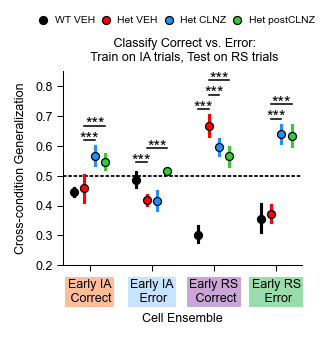

In [21]:
train_data = 'train_Early_IA_Correct_Early_IA_Error'
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
posthoc_df = plot_cross_condition_generalization_performance(ax_plot,
                                                             decode_out_distrib,
                                                             decoding_col = 'classes decoded',
                                                             decode_comp = 'Early IA Correct Early IA Error v Early RS Correct Early RS Error',
                                                             enriched_group = 'enriched_group',
                                                             ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'],
                                                             posthoc_comparisons= preset_comparison_list, 
                                                             marker_params= geno_color_dict_no_errorbar,
                                                             ylim =[0.2, 0.85],   
                                                             verbose_titles= verbose_dicts[train_data],
                                                             scale = 1.)
add_xtick_color_boxes(ax_plot,['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'], stage_palette_dict)
hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None)
##save fig 
fig_name = f"CCGP- {verbose_dicts[train_data][1]}_Early stage ens_ {date_tag}"
save_plot_record_as_csv_txt(posthoc_df,"3",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=3, filetypes_to_save = ['pdf', 'png','svg'])

#### Figure 4B - CCGP for models trained on Correct (IA/RS) and tested on Error (IA/RS)

Saved 4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_all_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_posthoc_results_text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\05_Mar_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


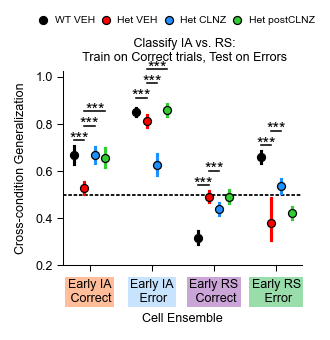

In [22]:
## figure params 
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
posthoc_df = plot_cross_condition_generalization_performance(ax_plot,decode_out_distrib,
    decoding_col = 'classes decoded',
    decode_comp = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error',
    enriched_group = 'enriched_group',
    ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'],
    posthoc_comparisons= preset_comparison_list,
    marker_params= geno_color_dict_no_errorbar,
    verbose_titles= verbose_dicts[train_data],scale = 1.)
##ax modifiers
add_xtick_color_boxes(ax_plot, ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'], stage_palette_dict)
hand, labs =ax_plot.get_legend_handles_labels() 
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None, )
##save fig_posthoc 
fig_name = f"SVM generalize (early ens) train_correct_test_error accuracy"
save_plot_record_as_csv_txt(posthoc_df,"4",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=4, filetypes_to_save = ['png','svg'])

## Plot the specific breakdown of classes predicted by CCG models

In [23]:
#cols to keep
confusion_mat_cols = ['true_pos','false_neg', 'false_pos', 'true_neg']
class_list = ['class_0_train','class_1_train','class_0_test','class_1_test']
run_ID_cols = ['geno_day','accuracy','pseudopop_run_num']



In [24]:
def transform_confusion_cols(decoding_results = pd.DataFrame,
                             confusion_mat_cols = confusion_mat_cols,
                             run_ID_cols = run_ID_cols,
                             class_list = class_list):
    df = decoding_results.loc[:,['enriched_group']+run_ID_cols +confusion_mat_cols + ['total'] + class_list].rename({'enriched_group':'ensemble'},axis = 1)
    df[class_list] = df[class_list].astype(str)

    # 3. Build all new columns w. vectorized string operations
    df = df.assign(
        train_on = 'train_' + df['class_0_train'] + '_x_' + df['class_1_train'],
        test_on  = 'test_'  + df['class_0_test']  + '_x_' + df['class_1_test'],
        Predict_class_1_train_x_Actual_class_1_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_1_test']),
        Predict_class_0_train_x_Actual_class_1_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_1_test']),
        Predict_class_1_train_x_Actual_class_0_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_0_test']),
        Predict_class_0_train_x_Actual_class_0_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_0_test'])
    )
    confusion_names = ['Predict_class_1_train_x_Actual_class_1_test',
                    'Predict_class_0_train_x_Actual_class_1_test',
                    'Predict_class_1_train_x_Actual_class_0_test', 
                    'Predict_class_0_train_x_Actual_class_0_test']
    # 4. reset index and melt
    grouped = df[['ensemble', 'train_on','test_on'] +confusion_mat_cols + run_ID_cols+ confusion_names].set_index(['train_on', 'test_on','ensemble'])
    df= grouped.reset_index().melt(value_vars = ['true_pos', 'false_neg', 'false_pos', 'true_neg'], 
                                id_vars = ['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy', 'pseudopop_run_num'] + confusion_names)

    # 5. Define the mapping from your “variable” names to the Predict_… columns
    col_map = {'true_pos':  'Predict_class_1_train_x_Actual_class_1_test',
               'false_neg': 'Predict_class_0_train_x_Actual_class_1_test',
               'false_pos': 'Predict_class_1_train_x_Actual_class_0_test',
               'true_neg':  'Predict_class_0_train_x_Actual_class_0_test'}
    
    df['var_column'] = df['variable'].map(col_map) #name of column containing var info
    df['labels'] = df.apply(lambda row: row[row['var_column']],axis=1)
    df[['predict', 'actual']] = df.labels.str.split("_x_", expand = True)
    rename_df = df[['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy','pseudopop_run_num','value','labels', 'predict', 'actual', 'var_column', 'variable']].set_index(("train_on")).copy()
    rename_df.loc[:,'actual'] = rename_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
    rename_df['value'] = rename_df['value']*2
    return rename_df 

In [25]:
CCGP_prediction_df = transform_confusion_cols(decoding_results=decode_out_distrib, confusion_mat_cols = confusion_mat_cols, run_ID_cols = run_ID_cols, class_list = class_list)
CCGP_prediction_df

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.674805,0,0.928125,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.694824,0,0.846250,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Early RS Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.555176,0,0.613750,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,Het CLNZ,0.561035,0,0.581250,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Early IA Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.509277,0,0.524375,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
...,...,...,...,...,...,...,...,...,...,...,...
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Late_RS,WT CLNZ,0.533203,9999,0.373750,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,Predict_Early_RS_Correct,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Late_RS,WT VEH,0.557617,9999,1.000000,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct,Early IA Error,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Late_RS,WT VEH,0.566406,9999,0.970000,Predict_Early_IA_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg


In [ ]:

# ## transform value 
# df = decode_out_distrib.loc[:,['enriched_group']+run_ID_cols +confusion_mat_cols + ['total'] + class_list].rename({'enriched_group':'ensemble'},axis = 1)
# df[class_list] = df[class_list].astype(str)

# # 3. Build all new columns w. vectorized string operations
# df = df.assign(
#     train_on = 'train_' + df['class_0_train'] + '_x_' + df['class_1_train'],
#     test_on  = 'test_'  + df['class_0_test']  + '_x_' + df['class_1_test'],
#     Predict_class_1_train_x_Actual_class_1_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_1_test']),
#     Predict_class_0_train_x_Actual_class_1_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_1_test']),
#     Predict_class_1_train_x_Actual_class_0_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_0_test']),
#     Predict_class_0_train_x_Actual_class_0_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_0_test'])
# )
# confusion_names = ['Predict_class_1_train_x_Actual_class_1_test',
#                    'Predict_class_0_train_x_Actual_class_1_test',
#                    'Predict_class_1_train_x_Actual_class_0_test', 
#                    'Predict_class_0_train_x_Actual_class_0_test']
# # 4. reset index and melt
# grouped = df[['ensemble', 'train_on','test_on'] +confusion_mat_cols + run_ID_cols+ confusion_names].set_index(['train_on', 'test_on','ensemble'])
# df= grouped.reset_index().melt(value_vars = ['true_pos', 'false_neg', 'false_pos', 'true_neg'], 
#                                id_vars = ['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy', 'pseudopop_run_num'] + confusion_names)

# # 5. Define the mapping from your “variable” names to the Predict_… columns
# col_map = {'true_pos':  'Predict_class_1_train_x_Actual_class_1_test','false_neg': 'Predict_class_0_train_x_Actual_class_1_test','false_pos': 'Predict_class_1_train_x_Actual_class_0_test','true_neg':  'Predict_class_0_train_x_Actual_class_0_test'}
# df['var_column'] = df['variable'].map(col_map) #name of column containing var info
# df['labels'] = df.apply(lambda row: row[row['var_column']],axis=1)
# df[['predict', 'actual']] = df.labels.str.split("_x_", expand = True)
# input_df = df[['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy','pseudopop_run_num','value','labels', 'predict', 'actual', 'var_column', 'variable']].set_index(("train_on")).copy()
# input_df.loc[:,'actual'] = CCGP_prediction_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
# input_df['value'] = input_df['value']*2


In [27]:
def plot_ccg_confusion_single_proportion(ax,
                                         proportion_df,
                                         train,
                                         ens,
                                         prediction_class = "Predict_Early_RS_Correct",
                                         genos_to_plot = geno_order,
                                         errorbar = ('pi', 95),
                                         ylim=[0, 0.515],
                                         title_type = {'train_Early_IA_Correct_x_Early_RS_Correct':'Classification (IA vs. RS) of',
                                                       'train_Early_IA_Correct_x_Early_IA_Error': 'Classification (correct vs. error) of'},
                                         **kwargs):
    ''' started 6/25/25- To plot distributions of ccg''' 
    #modify df for better plot
    proportion_df = proportion_df.loc[train,:].reset_index()
    plot_df = proportion_df.loc[proportion_df.ensemble == ens,:].copy()
    plot_df.loc[:,'actual'] = plot_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
    #given you plot only one type, filter by type
    plot_df = plot_df.loc[plot_df.predict == prediction_class,:]
    plot_df['value'] = plot_df['value'] *100 #multiply by 100 to return percent
    stage_order = sorted(set(plot_df.loc[:,'actual']))
    plot_params = dict(data = plot_df,ax = ax,x = 'actual', y = 'value', dodge = 0.5, linestyles = 'none',order = stage_order,errorbar = errorbar, 
                       **{True:geno_order_w_WT_CLNZ_no_eb, False:geno_color_dict_no_errorbar}["WT CLNZ" in genos_to_plot])
    s = sns.pointplot(**plot_params)
    ###modify ax decorators
    set_pointplot_edgecolor(ax)
    ax_title = f"{title_type[train]}\n activity in {ens.replace('_', ' ')} ensemble"
    ylabel_options = {'train_Early_IA_Correct_x_Early_IA_Error': 'Correct',
                      'train_Early_IA_Correct_x_Early_RS_Correct':'RS'}
    set_labels(ax, label_dict = {'title':ax_title,
                                 'legend_false':True, 
                                 'xlabel':f"Test Data Stage",
                                 'ylim':ylim, 'ylabel': f"% Classified as {ylabel_options[train]}"})
    #run posthoc test 
    if "WT CLNZ" in plot_params['hue_order']: #NEW- alternate what comparison list to use based on if WT-CLNZ in hue_order or not
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    # Draw canvas to ensure error bar coordinates are computed (fixes multi-subplot issue)
    ax.figure.canvas.draw()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, s, comparisons, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.0175,offset_constant = 0.0085) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    #more ax tuning
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels())) 
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 100])
    return posthoc_df

#### Figure 3C: CCG model classifications of activity of Early RS Correct ensemble 

Saved 3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


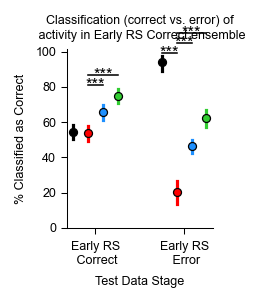

In [28]:
##Figure 3- TRAIN IA
ensemble = "Early_RS_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'tight')
posthoc_df = plot_ccg_confusion_single_proportion(ax, CCGP_prediction_df,
                                                  train = 'train_Early_IA_Correct_x_Early_IA_Error',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order,
                                                  prediction_class= "Predict_Early_IA_Correct",
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, None],)
##savefig 
fig_num = 3
fig_name = f"CCG single class pred- Train IA test RS - {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix= "predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Figure 4C: % of samples classified as RS, for activity from Early IA Correct ensemble

Saved 4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


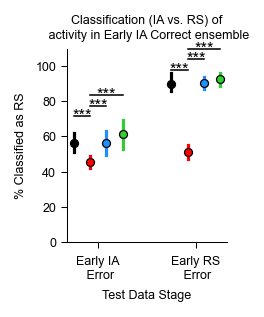

In [30]:
ensemble = "Early_IA_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, CCGP_prediction_df,
                                       train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                       ens= ensemble,
                                       genos_to_plot = geno_order,
                                       prediction_class = "Predict_Early_RS_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 110])
##savefig 
fig_num = 4
fig_name = f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None,
                        csv_suffix="predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Figure 4F: % of samples classified as RS, for activity from Early RS Error ensemble

Saved 4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


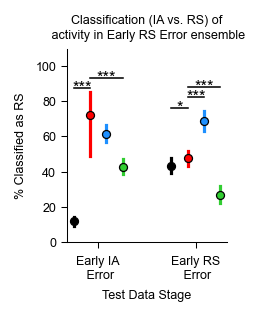

In [31]:
ensemble = "Early_RS_Error"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax,CCGP_prediction_df,
                                                  train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order ,
                                                  prediction_class= "Predict_Early_RS_Correct",
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 110],)
##savefig 
fig_num = 4
fig_name = f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix="predict_posthoc cohen d",txt_suffix="predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### supplement uniproportion CCG classes

switching posthoc comparison to include WT CLNZ
Saved 2_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


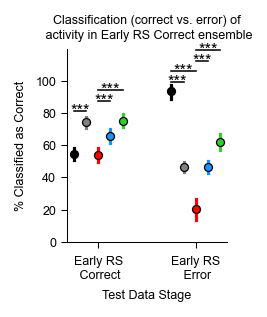

In [33]:
## SUPP Figure 3- TRAIN IA
ensemble = "Early_RS_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, CCGP_prediction_df,
                                       train = 'train_Early_IA_Correct_x_Early_IA_Error',
                                       ens= ensemble,
                                       genos_to_plot = geno_order_w_WT_CLNZ,
                                       prediction_class= "Predict_Early_IA_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 120],)
##savefig 
fig_num = 3
fig_name = f"supp_CCG single class pred- Train IA test RS - {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"2_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix=f"supp_predict_posthoc cohen d",txt_suffix=f"supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f"s_2", filetypes_to_save = ['png','svg'])

switching posthoc comparison to include WT CLNZ
Saved 2_s_supp_CCG 1_class pred-Train_Correct_Test_Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_CCG 1_class pred-Train_Correct_Test_Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


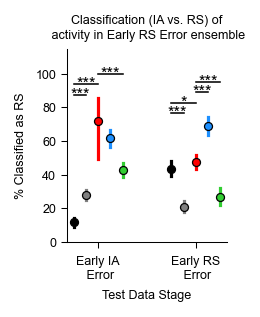

In [34]:
#SUPP FIGURE 4
ensemble = "Early_RS_Error"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, CCGP_prediction_df,
                                                  train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order_w_WT_CLNZ,
                                                  prediction_class= "Predict_Early_RS_Correct",
                                                  errorbar = ('pi', 75),ylim=[0, 115])
##savefig 
fig_num = 4
fig_name = f"supp_CCG 1_class pred-Train_Correct_Test_Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"2_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_2', filetypes_to_save = ['png','svg'])

switching posthoc comparison to include WT CLNZ
Saved 2_s_supp_CCG 1_class pred-Train_Correct_Test_Error-Early_IA_Correct ensemble_supp_predict_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_CCG 1_class pred-Train_Correct_Test_Error-Early_IA_Correct ensemble_supp_predict_posthoc cohen d text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


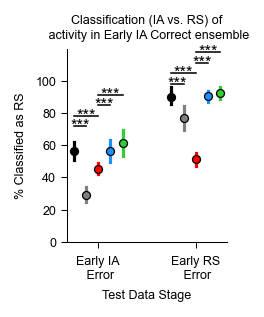

In [35]:
#FIGURE 4- IA Correct
ensemble = "Early_IA_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, CCGP_prediction_df,
                                       train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                       ens= ensemble,
                                       genos_to_plot = geno_order_w_WT_CLNZ, #specify if including WT CLNZ
                                       prediction_class= "Predict_Early_RS_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 120])
##savefig 
fig_num = 4
fig_name = f"supp_CCG 1_class pred-Train_Correct_Test_Error-{ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"2_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_2', filetypes_to_save = ['png','svg'])

## Linear SVM Plots (Figures: 5-7 + S2)

In [36]:
def plot_decode_accuracy_ensemble_subset(pop_mean_decoding,
                                         decoding_col, 
                                         decoder_comparison, 
                                         ensemble_col,
                                         ax_plot,
                                         ensemble_subset=None, 
                                         ylim = [0.8, 1.05],
                                         plot_config = geno_color_dict_no_errorbar,
                                        **kwargs):
    ''' TO- plot 1 panel of SVM accuracy for 1 class decoding comparison, for all ensemble groups ued for decoding. inputs: plot config- usually contains geno_color_dict/ describes default paleete info, etc ''' 
    verbose_decoded_pairs = ['IA activity as Early IA vs Early RS', 'Correct activity as Early IA vs Early RS', 'IA activity as Early IA vs Late IA','Error activity as Early IA vs Early RS',
    'RS activity as Correct vs Error', 'RS activity as Early RS vs Late', 'activity as Late IA vs Early RS Correct', 'Late activity as Late IA vs Late RS']
    verbose_titles = {pair:verb  for verb, pair in zip(verbose_decoded_pairs,pop_mean_decoding['classes decoded'].unique().tolist())}
    verbose_titles
    if ensemble_subset == None:
        ensemble_subset= pop_mean_decoding[ensemble_col].unique()
    plot_df =  pop_mean_decoding.loc[(pop_mean_decoding[decoding_col] == decoder_comparison)&(pop_mean_decoding[ensemble_col].isin(ensemble_subset)) ,:]
    plot_params = {'data':plot_df, 'dodge': 0.35, 'markers': 'o',
                   'x': 'enriched_group', 'y':'accuracy', 'order':[x for x in phase_list_IA_RS_chrono if x in ensemble_subset ],
                   'errorbar': ('pi', 75), 'errwidth': 1.25, **plot_config}
    sc = sns.pointplot(ax = ax_plot, linestyles = 'none', **plot_params)#make cosine sim plot itself
    ## ax level changes
    verbose_decode = verbose_titles[decoder_comparison].replace("as", "as:\n").replace('_', ' ')
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)
    set_ax_title_xlabel_ylabel(ax_plot, {'title':f"Classify {verbose_decode}", 'ylim': ylim,
                                         'xlabel': "Cell Ensemble", 'ylabel': 'Mean accuracy', 'legend_false':False})#adjust plot information
    if "WT CLNZ" in plot_params['hue_order']:#Switch comparison list to use, if WT-CLNZ in hue_order or not
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, comparisons, test_name = 'cohen_d',detect_error_bar=True)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True,tight_offset = 0.04,offset_constant = 0.01) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    ##format ax 
    ax_plot.figure.canvas.draw()    # Draw canvas to ensure tick labels are computed (fixes multi-subplot timing issue)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    add_xtick_color_boxes(ax_plot, ensemble_subset, stage_palette_dict)
    return posthoc_df

def plot_save_ensemble_svm_accuracy(decoding_df,
                                    decoder_comparison:str,
                                    ensemble_subset:list= [],
                                    decoding_col:str = 'classes decoded', 
                                    figsize =(1.65,2), 
                                    fig_layout = 'tight',
                                    bbox_to_anchor=(0.7, .975),
                                    ylim = [0.90,1.015],
                                    fig_name = None,
                                    fig_folder=5,
                                    figure_prefix= "",
                                    add_legend = False,
                                    **kwargs):
        
    fig, ax = plt.subplots(1,1, figsize =figsize, layout = fig_layout)
    posthoc_df = plot_decode_accuracy_ensemble_subset(decoding_df, decoding_col, 
                                                      decoder_comparison, 'enriched_group',
                                                      ax_plot = ax,
                                                      ensemble_subset= ensemble_subset,
                                                      ylim = ylim,
                                                      **kwargs)
    #fix,tune axes
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 1.0])
    if add_legend:
        hand, labs =ax.get_legend_handles_labels() 
        fig.legend(hand, labs, bbox_to_anchor=(0.55, .975),loc = 'lower center', ncols = 4, frameon = False, title =None, **{
            'labelspacing': 0.0, 'markerscale': 1, 'borderpad': 0.0, 'columnspacing': 0.0, 'handletextpad': 0.0})
    #save figs 
    if fig_name is None:
        fig_name = f"SVM classifier accuracy {decoder_comparison} by ensemble"
    fig_name =  "_".join([figure_prefix,fig_name])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_folder, filetypes_to_save = ['png', 'svg'])
    posthoc_df['plot_name'] = fig_name
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_folder}",
                                fig_name,
                                csv_folder_most_recent, None,
                                csv_suffix="posthoc decode acc cohen D",txt_suffix="posthoc_text")
    return fig, ax,posthoc_df 


#### Figure 5C: SVM accuracy classifying Errors as Early IA vs Early RS, using Early RS Error or Early IA Error Ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5\05_Mar_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.
Saved 5_5C_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc decode acc cohen D_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\5_5C_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc_text_05_Mar_2026.txt


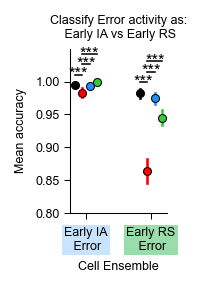

In [37]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Error_v_Early_RS_Error',
ensemble_subset = ['Early_IA_Error', 'Early_RS_Error'],ylim = [0.80,1.05], figsize = (1.25,1.90),fig_folder=5,  figure_prefix= "5C" )

#### Figure 5D: Time-based classification of Early IA Error vs Early RS Error, using Early RS Error ensemble data

In [38]:
def plot_ensemble_value_at_timebin(
    ax_plot, 
    timebin_values,
    ensemble,
    y_val,
    **kwargs):
    ''' Plot  time-bin bootstrapped metric for a given ensemble, for a given pair of classes to compare'''  

    plot_df = timebin_values.loc[timebin_values.enriched_group == ensemble,:].dropna()
    plot_df['bin_name'] = plot_df['bin_name'].str.replace(".0s to ", "-").str.replace(".0s", "").str.replace("--", "-")#rename bin
    plot_params = {'data': plot_df,  'x': 'bin_name', 'y' : y_val, 'errorbar': ('pi', 75), 'errwidth': 1.25, 'order': plot_df['bin_name'].unique(),
                  **kwargs, **geno_color_dict_no_errorbar}
    sc = sns.pointplot(ax = ax_plot, **plot_params,  )#make cosine sim plot itself
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)    # ax_plot.legend_.remove()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, preset_comparison_list, test_name = 'cohen_d',detect_error_bar = True)
    return posthoc_df

def plot_save_time_dep_decoding(
    decoding_df,
    decoding_col,
    decoding_metric = 'mean_acc',
    decoder_comparison = None,
    ensemble = None,
    ylim = [0.825,1.04],
    figsize = (1.75,1.75),
    fig_num=5,
    figure_prefix = "5D",
    use_verbose_title = True):
    ''' main script to plot time-dependent accuracy and save values ''' 
    verbose_decoded_pairs = ['IA activity as Early IA vs Early RS', 'Correct activity as Early IA vs Early RS', 'IA activity as Early IA vs Late IA','Error activity as Early IA vs Early RS',
    'RS activity as Correct vs Error', 'RS activity as Early RS vs Late', 'activity as Late IA vs Early RS Correct', 'Late activity as Late IA vs Late RS']
    verbose_titles = {pair:verb  for verb, pair in zip(verbose_decoded_pairs,pop_mean_decoding['classes decoded'].unique().tolist())}
    verbose_titles
    fig, ax_plot = plt.subplots(1, 1, figsize = figsize, layout = 'constrained')
    
    time_decode_classes = decoding_df.loc[decoding_df[decoding_col] == decoder_comparison,:]
    posthoc_df = plot_ensemble_value_at_timebin(ax_plot, time_decode_classes, ensemble, decoding_metric, dodge = True)
    
    #for plotting titles
    decoder_comparison_clean = decoder_comparison.replace('_', ' ')
    ensemble_clean = ensemble.replace('_', ' ')
    if use_verbose_title:
        ax_title = f'{ensemble_clean} ensemble:\nClassify {verbose_titles[decoder_comparison]}'
    else:
        ax_title = f'{ensemble_clean} ensemble:\n Decoding {decoder_comparison_clean}'
    set_ax_title_xlabel_ylabel(ax_plot, {'title':ax_title, 'legend_false':True,'xlabel': f"Decoded time window (s)", 
    'xtick_rotation':  {'rotation':30}, 'ylabel': 'Decoding Accuracy'})
    ax_plot.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.2f}"))
    
    ##savefig
    fig_name = "_".join([figure_prefix, f'{ensemble_clean} ensemble time-based classification of {decoder_comparison_clean}'])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=stage_to_fig[(decoder_comparison,ensemble)],  filetypes_to_save = ['png', 'svg'])
    #new- save posthoc, CSV
    posthoc_df['plot_name'] = ax_title
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_num}",
                                fig_name,
                                csv_folder_most_recent, None,
                                csv_suffix="posthoc acc cohen D",txt_suffix="posthoc_text")
    return fig, ax_plot,posthoc_df 

#### Figure 6C: Early IA/RS Correct - SVM accuracy for Early RS Error Ensemble

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\05_Mar_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.
Saved 6_6C_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\6_6C_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc_text_05_Mar_2026.txt


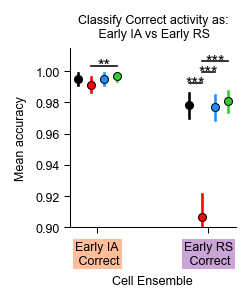

In [39]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct', 
    ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct'],ylim = [0.9, 1.015], figure_prefix = "6C", fig_folder=6)

#### Figure 6D: Time-based classification of Correct as Early IA vs Early RS, using Early RS Correct ensemble data


In [40]:
time_decode_scores

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name,run_source_dataset,run_end_date,dataset_label
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[0, 11]",0,11,-3.0s,1.000000,-0.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,-3.0s to -0.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[12, 23]",12,23,0.0s,0.997559,3.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,0.0s to 3.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[24, 35]",24,35,3.0s,1.000000,6.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,3.0s to 6.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[36, 47]",36,47,6.0s,1.000000,9.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,6.0s to 9.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[48, 59]",48,59,9.0s,1.000000,12.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,9.0s to 12.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1439995,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[12, 23]",12,23,0.0s,0.883789,3.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,0.0s to 3.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439996,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[24, 35]",24,35,3.0s,0.951172,6.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,3.0s to 6.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439997,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[36, 47]",36,47,6.0s,0.952637,9.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,6.0s to 9.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439998,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[48, 59]",48,59,9.0s,0.895020,12.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,9.0s to 12.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.
Saved 6_6D_Early RS Correct ensemble time-based classification of Early IA Correct v Early RS Correct_posthoc acc cohen D_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\6_6D_Early RS Correct ensemble time-based classification of Early IA Correct v Early RS Correct_posthoc_text_05_Mar_2026.txt


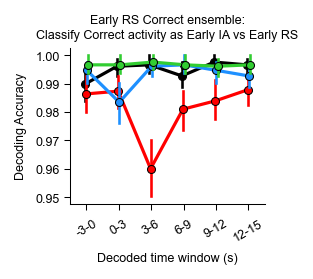

In [41]:
fig, ax,posthoc_df= plot_save_time_dep_decoding(time_decode_scores,decoding_col = "classes decoded", decoding_metric = 'mean_acc', decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct',
    ensemble ='Early_RS_Correct', figsize = (1.75,1.75),figure_prefix = "6D", fig_num=6)

#### Figure 7C: SVM accuracy at classifying Early IA Correct vs. Late IA, using Early IA Correct/Late IA ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\05_Mar_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.
Saved 7_7_C_SVM classifier accuracy Early_IA_Correct_v_Late_IA by ensemble_posthoc decode acc cohen D_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\7_7_C_SVM classifier accuracy Early_IA_Correct_v_Late_IA by ensemble_posthoc_text_05_Mar_2026.txt


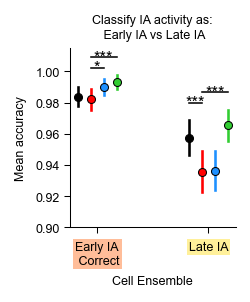

In [42]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Late_IA',
ensemble_subset = ['Early_IA_Correct', 'Late_IA'],figure_prefix = "7_C",fig_folder=7)

#### Figure 7G: SVM accuracy at classifying Early RS Correct vs. Late IA, using Early RS Correct/Late IA ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.
Saved 7_7_G_SVM classifier accuracy Late_IA_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\7_7_G_SVM classifier accuracy Late_IA_v_Early_RS_Correct by ensemble_posthoc_text_05_Mar_2026.txt


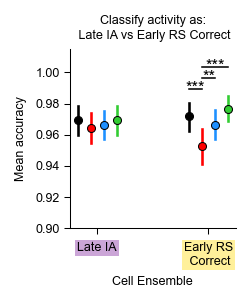

In [43]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Late_IA_v_Early_RS_Correct', 
    ensemble_subset = ['Early_RS_Correct', 'Late_IA'],figure_prefix = "7_G", fig_folder= 7)

#### Supplementary Figure 2F: SVM accuracy classifying Errors as Early IA vs Early RS, using Early RS Error or Early IA Error Ensemble data (showing WT CLNZ)

switching posthoc comparison to include WT CLNZ
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.
Saved s_2_S2_F_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc decode acc cohen D_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\s_2_S2_F_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc_text_05_Mar_2026.txt


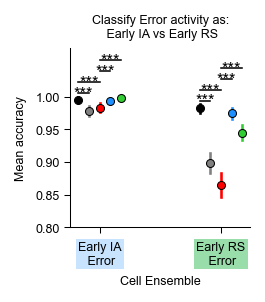

In [44]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Error_v_Early_RS_Error',
 ensemble_subset = ['Early_IA_Error', 'Early_RS_Error'], ylim = [0.82,1.075], figsize = supp_svm_panel_size,
 figure_prefix = "S2_F", fig_folder= 's_2', plot_config = geno_order_w_WT_CLNZ_no_eb)

#### Supplementary Figure 2H: SVM accuracy classifying Correct as Early IA vs Early RS, using Early IA or RS Correct Ensemble data (showing WT CLNZ)

switching posthoc comparison to include WT CLNZ
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.
Saved s_2_S2_H_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\s_2_S2_H_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc_text_05_Mar_2026.txt


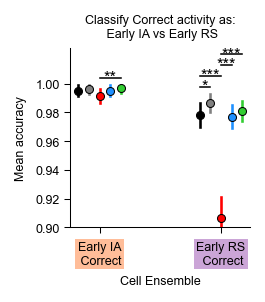

In [45]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct',
 ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct'], ylim = [0.9,1.025], figsize = supp_svm_panel_size,
  figure_prefix = "S2_H", fig_folder='s_2', plot_config = geno_order_w_WT_CLNZ_no_eb)

## Summary Figure: All SVM Classifier Accuracy Plots

Combined view of all ensemble SVM accuracy comparisons from Figures 5, 6, 7, and Supplemental Figure 2.

{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Error_v_Early_RS_Error', 'ensemble_subset': ['Early_IA_Error', 'Early_RS_Error'], 'ylim': [0.8, 1.05], 'title': '5C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Correct_v_Early_RS_Correct', 'ensemble_subset': ['Early_IA_Correct', 'Early_RS_Correct'], 'ylim': [0.9, 1.015], 'title': '6C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Correct_v_Late_IA', 'ensemble_subset': ['Early_IA_Correct', 'Late_IA'], 'ylim': [0.9, 1.015], 'title': '7C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_compa

Text(0.5, 0.98, 'Summary: SVM Classifier Accuracy by Ensemble')

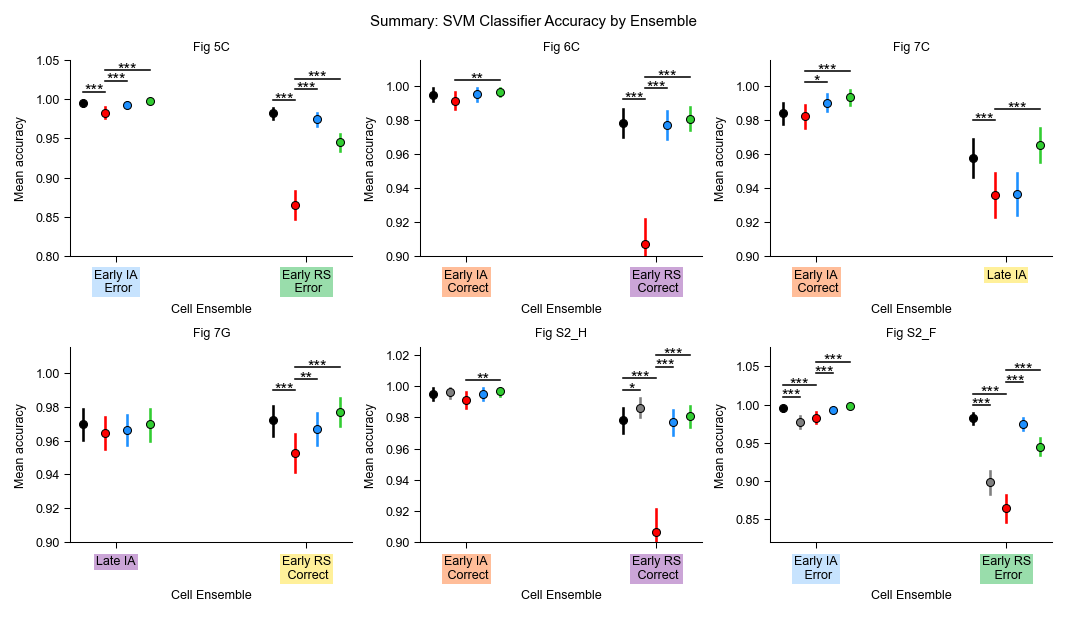

In [46]:
# Summary figure combining all SVM accuracy plots
fig, axes = plt.subplots(2, 3, figsize=(7, 4), layout="constrained")

# Define all plot configurations
plot_configs = [
    # Row 1
    {"ax": axes[0, 0], "decoder_comparison": "Early_IA_Error_v_Early_RS_Error",
     "ensemble_subset": ["Early_IA_Error", "Early_RS_Error"], "ylim": [0.80, 1.05],
     "title": "5C", "plot_config": geno_color_dict_no_errorbar},
    {"ax": axes[0, 1], "decoder_comparison": "Early_IA_Correct_v_Early_RS_Correct",
     "ensemble_subset": ["Early_IA_Correct", "Early_RS_Correct"], "ylim": [0.9, 1.015],
     "title": "6C", "plot_config": geno_color_dict_no_errorbar},
    {"ax": axes[0, 2], "decoder_comparison": "Early_IA_Correct_v_Late_IA",
     "ensemble_subset": ["Early_IA_Correct", "Late_IA"], "ylim": [0.90, 1.015],
     "title": "7C", "plot_config": geno_color_dict_no_errorbar},
     # Row 2
    {"ax": axes[1, 0], "decoder_comparison": "Late_IA_v_Early_RS_Correct",
     "ensemble_subset": ["Early_RS_Correct", "Late_IA"], "ylim": [0.90, 1.015],
     "title": "7G", "plot_config": geno_color_dict_no_errorbar},
     
     #supp 
     {"ax": axes[1, 1], "decoder_comparison": "Early_IA_Correct_v_Early_RS_Correct",
     "ensemble_subset": ["Early_IA_Correct", "Early_RS_Correct"], "ylim": [0.9, 1.025],
     "title": "S2_H", "plot_config": geno_order_w_WT_CLNZ_no_eb},
       {"ax": axes[1, 2], "decoder_comparison": "Early_IA_Error_v_Early_RS_Error",
     "ensemble_subset": ["Early_IA_Error", "Early_RS_Error"], "ylim": [0.82, 1.075],
     "title": "S2_F", "plot_config": geno_order_w_WT_CLNZ_no_eb},
]

# Generate each subplot
for config in plot_configs:
    print(config)
    plot_decode_accuracy_ensemble_subset(
        pop_mean_decoding,
        decoding_col="classes decoded",
        decoder_comparison=config["decoder_comparison"],
        ensemble_col="enriched_group",
        ax_plot=config["ax"],
        ensemble_subset=config["ensemble_subset"],
        ylim=config["ylim"],
        plot_config=config["plot_config"]
    )
    config["ax"].set_title(f"Fig {config['title']}", )

plt.suptitle("Summary: SVM Classifier Accuracy by Ensemble",)

# # Save the summary figure
# save_fig_in_main_fig_dir(fig, fig_name="Summary_SVM_classifier_accuracy_all_comparisons", 
#                         folder_key="1", filetypes_to_save=["png", "svg"])

## NEW- Null band w. label-permut 

#### CCGP with Null bands:

In [47]:
latest_runs

,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved,run_datetime
0,0,15_Feb_2026,in_distribution,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,2026-02-15 00:13:30.600000
4,4,16_Feb_2026,out_of_distribution,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,2026-02-16 00:49:14.400000
2,2,15_Feb_2026,out_of_distribution_label_permuted,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,2026-02-15 00:13:30.600000
5,5,16_Feb_2026,out_of_distribution_whole_pop,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,2026-02-16 00:49:14.400000
6,6,04_Mar_2026,out_of_distribution_whole_pop_permuted,2026-03-04 14:51:43.921476,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,2026-03-04 14:51:43.921476
3,3,15_Feb_2026,timebin_decoding,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,2026-02-15 00:13:30.600000


In [48]:
decode_dfs.keys()

dict_keys(['decode_scores', 'decode_out_distrib', 'decode_out_distrib_label_permuted', 'decode_out_distrib_whole_pop', 'decode_out_distrib_whole_pop_permuted', 'time_decode_scores'])

In [49]:
# Load label-permuted CCGP data from run info
# label_perm_filename = latest_runs.loc[latest_runs['decoding_type'] == 'out_of_distribution_label_permuted', 'run_output_filename'].values[0]
# print(f"Loading label-permuted CCGP data from file: {label_perm_filename}")
# decode_out_distrib_label_permuted = pd.read_parquet(label_perm_filename)

decode_out_distrib_label_permuted = decode_dfs.get('decode_out_distrib_label_permuted')
# Apply same column transformations as for the new data
decode_out_distrib_label_permuted['train_on'] = decode_out_distrib_label_permuted['class_0_train'].str.cat(decode_out_distrib_label_permuted['class_1_train'], sep="_").str.replace('_', ' ')
decode_out_distrib_label_permuted['test_on'] = decode_out_distrib_label_permuted['class_0_test'].str.cat(decode_out_distrib_label_permuted['class_1_test'], sep="_").str.replace('_', ' ')
decode_out_distrib_label_permuted['classes decoded'] = decode_out_distrib_label_permuted['train_on'].str.cat(decode_out_distrib_label_permuted['test_on'], sep=" v ")
decode_out_distrib_label_permuted['classes decoded'] = decode_out_distrib_label_permuted['classes decoded'].str.replace('_', ' ')
decode_out_distrib_label_permuted['total'] = decode_out_distrib_label_permuted['true_pos'] + decode_out_distrib_label_permuted['false_neg'] + decode_out_distrib_label_permuted['false_pos'] + decode_out_distrib_label_permuted['true_neg']

print(f"Loaded label-permuted CCGP data: {len(decode_out_distrib_label_permuted)} rows")
print(f"Current (new) CCGP data: {len(decode_out_distrib)} rows")
decode_out_distrib_label_permuted.head()

Loaded label-permuted CCGP data: 1200000 rows
Current (new) CCGP data: 1200000 rows


,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,training_label_permuted,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,...,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label,classes decoded,total
0,0.519531,79.0,79.0,0.261875,0.257500,0.242500,0.238125,1.0,0.616699,0.673828,...,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.602051,79.0,60.0,0.303750,0.298438,0.201562,0.196250,1.0,0.478027,0.673828,...,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles,Early IA Error Early RS Error v Early IA Corre...,1.0
2,0.491699,79.0,79.0,0.194062,0.297500,0.202500,0.305937,1.0,0.673828,0.616699,...,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early IA Error,Early RS Correct Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles,Early IA Correct Early IA Error v Early RS Cor...,1.0
3,0.494629,79.0,55.5,0.228750,0.265938,0.234063,0.271250,1.0,0.690430,0.616699,...,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early RS Correct Early RS Error,Early IA Correct Early IA Error,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles,Early RS Correct Early RS Error v Early IA Cor...,1.0
4,0.530273,28.0,28.0,0.275625,0.254688,0.245312,0.224375,1.0,0.594238,0.757812,...,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles,Early IA Correct Early RS Correct v Early IA E...,1.0


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


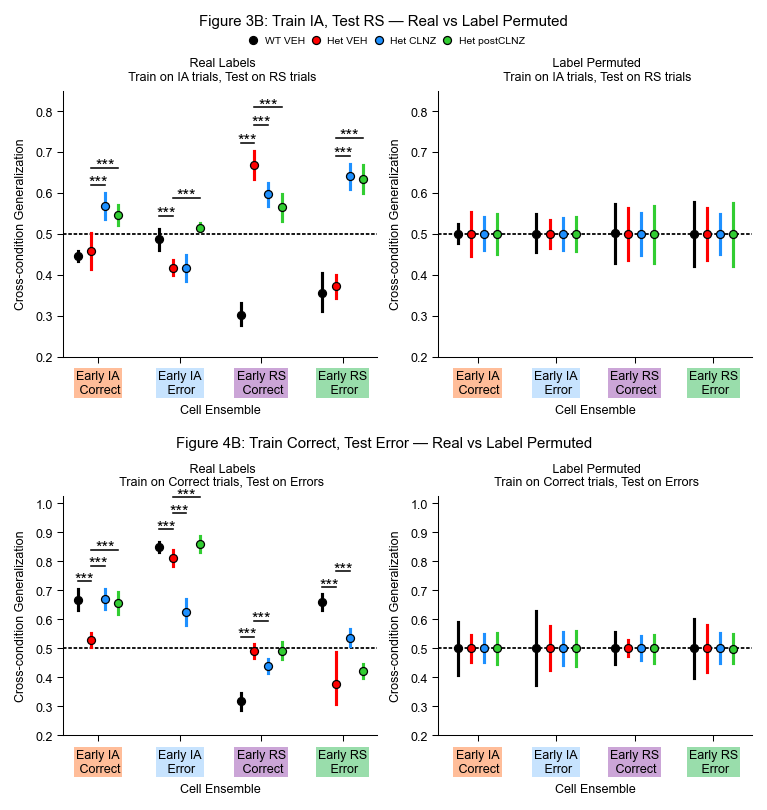

In [50]:
fig = plt.figure(figsize = (5,5), layout = 'constrained')
subfigs = fig.subfigures(2,1,)
axes = subfigs[0].subplots(1, 2)

# Figure 3B comparison: Train on IA, Test on RS
train_data = 'train_Early_IA_Correct_Early_IA_Error'
decode_comp_3b = 'Early IA Correct Early IA Error v Early RS Correct Early RS Error'
ensembles_3b = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

# New data (left)
posthoc_df_new_3b = plot_cross_condition_generalization_performance(
    axes[0], decode_out_distrib,
    decoding_col='classes decoded', decode_comp=decode_comp_3b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85], verbose_titles=['Real Labels', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[0], ensembles_3b, stage_palette_dict)
if axes[0].get_legend():
    axes[0].get_legend().remove()

# Label-permuted data (right)
posthoc_df_perm_3b = plot_cross_condition_generalization_performance(
    axes[1], decode_out_distrib_label_permuted,
    decoding_col='classes decoded', decode_comp=decode_comp_3b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85], verbose_titles=['Label Permuted', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[1], ensembles_3b, stage_palette_dict)

# Shared legend
hand, labs = axes[1].get_legend_handles_labels()
if axes[1].get_legend():
    axes[1].get_legend().remove()
subfigs[0].legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc='lower center', ncols=4, frameon=False, title=None)
subfigs[0].suptitle('Figure 3B: Train IA, Test RS — Real vs Label Permuted', y=1.1)

## Figure 4B comparison: Train on Correct (IA/RS), Test on Error (IA/RS)
axes = subfigs[1].subplots(1, 2)
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
decode_comp_4b = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error'
ensembles_4b = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

# New data (left)
posthoc_df_new_4b = plot_cross_condition_generalization_performance(
    axes[0], decode_out_distrib,
    decoding_col='classes decoded', decode_comp=decode_comp_4b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025], scale=1.,
    verbose_titles=['Real Labels', verbose_dicts[train_data][1]])
add_xtick_color_boxes(axes[0], ensembles_4b, stage_palette_dict)
if axes[0].get_legend():
    axes[0].get_legend().remove()

# Label-permuted data (right)
posthoc_df_perm_4b = plot_cross_condition_generalization_performance(
    axes[1], decode_out_distrib_label_permuted,
    decoding_col='classes decoded', decode_comp=decode_comp_4b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025], verbose_titles=['Label Permuted', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[1], ensembles_4b, stage_palette_dict)

# Shared legend
hand, labs = axes[1].get_legend_handles_labels()
if axes[1].get_legend():
    axes[1].get_legend().remove()
subfigs[1].suptitle('Figure 4B: Train Correct, Test Error — Real vs Label Permuted')

## save combined subfigures into 1 figure
combined_fig_name = f"CCG_Compare_Fig3B_Fig4B_Real_vs_LabelPermuted"
save_fig_in_main_fig_dir(fig, fig_name= combined_fig_name, folder_key='s_2',  filetypes_to_save = ['png', 'svg'])

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


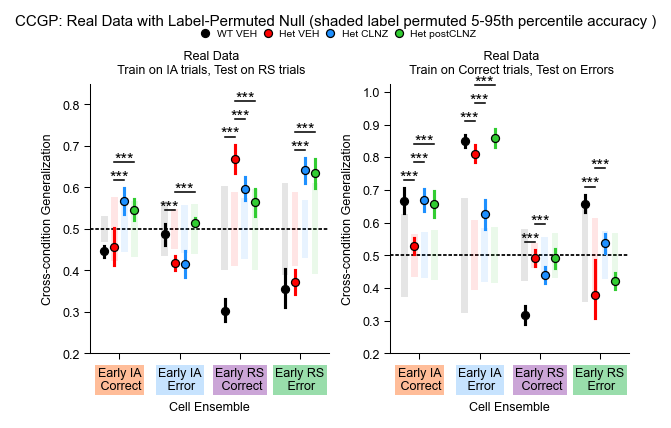

In [51]:
def add_null_bands(ax_plot, decode_permuted, decoding_col, decode_comp,
                   enriched_group, ensembles_to_plot, marker_params, dodge=0.5):
    """Overlay shaded bands showing 5th-95th percentile null distribution with edge lines."""
    hue_col = marker_params['hue']
    hue_order = marker_params['hue_order']
    palette = marker_params['palette']
    n_hue = len(hue_order)
    offsets = np.linspace(-dodge/2, dodge/2, n_hue)
    band_width = dodge / n_hue * 0.9

    perm_mask = (decode_permuted[decoding_col] == decode_comp) & (decode_permuted[enriched_group].isin(ensembles_to_plot))
    perm_df = decode_permuted.loc[perm_mask]

    for ens_idx, ensemble in enumerate(ensembles_to_plot):
        for hue_idx, geno in enumerate(hue_order):
            subset = perm_df.loc[(perm_df[enriched_group] == ensemble) & (perm_df[hue_col] == geno), 'accuracy']
            if len(subset) == 0:
                continue
            p5, p95 = subset.quantile(0.05), subset.quantile(0.95)
            x_center = ens_idx + offsets[hue_idx]
            x_left, x_right = x_center - band_width/2, x_center + band_width/2
            color = palette[hue_idx]
            # Shaded band: 5th-95th with edge lines
            ax_plot.fill_between(
                [x_left, x_right], p5, p95,
                color=color, alpha=0.1, zorder=0, linewidth=0)
            # ax_plot.hlines([p5, p95], x_left, x_right,colors=color, linewidths=0, linestyles='-', zorder=0.5)

# --- Figure: Real data overlaid with label-permuted null bands ---
fig, axes = plt.subplots(1, 2, figsize=(4, 2.5), layout='constrained')

# Figure 3B: Train on IA, Test on RS
train_data = 'train_Early_IA_Correct_Early_IA_Error'
decode_comp_3b = 'Early IA Correct Early IA Error v Early RS Correct Early RS Error'
ensembles_3b = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

posthoc_df_3b = plot_cross_condition_generalization_performance(
    axes[0], decode_out_distrib,
    decoding_col='classes decoded', decode_comp=decode_comp_3b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85], verbose_titles=['Real Data', verbose_dicts[train_data][1]], scale=1.)
add_null_bands(axes[0], decode_out_distrib_label_permuted,
               'classes decoded', decode_comp_3b, 'enriched_group', ensembles_3b, geno_color_dict_no_errorbar)
add_xtick_color_boxes(axes[0], ensembles_3b, stage_palette_dict)

# Figure 4B: Train on Correct, Test on Error
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
decode_comp_4b = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error'
ensembles_4b = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

posthoc_df_4b = plot_cross_condition_generalization_performance(
    axes[1], decode_out_distrib,
    decoding_col='classes decoded', decode_comp=decode_comp_4b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025], verbose_titles=['Real Data', verbose_dicts[train_data][1]], scale=1.)
add_null_bands(axes[1], decode_out_distrib_label_permuted,
               'classes decoded', decode_comp_4b, 'enriched_group', ensembles_4b, geno_color_dict_no_errorbar)
add_xtick_color_boxes(axes[1], ensembles_4b, stage_palette_dict)

# Clean up legends
for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()
hand, labs = axes[0].get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc='lower center', ncols=4, frameon=False)
fig.suptitle('CCGP: Real Data with Label-Permuted Null (shaded label permuted 5-95th percentile accuracy )', y=1.08)

## save fig:
combined_fig_name = "CCG_Real_vs_LabelPermuted_Overlay"
save_fig_in_main_fig_dir(fig, fig_name= combined_fig_name, folder_key='s_2',  filetypes_to_save = ['png', 'svg'])

In [52]:
def plot_cross_condition_generalization_performance_w_null(
    ax_plot,
    decode_out_distrib,
    decode_permuted,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    posthoc_comparisons,
    marker_params,
    ylim:list = [0.2, 1.025],
    verbose_titles:list = ["train IA", "test RS"],
    null_percentiles = (0.05, 0.95),
    **kwargs):
    
    """Plot CCGP accuracy with null bands, only plotting posthoc stat bars
    for comparisons where at least 1 group's median exceeds the null at that ensemble."""
    # Plot real data
    plot_mask = (decode_out_distrib[decoding_col] == decode_comp) & (decode_out_distrib[enriched_group].isin(ensembles_to_plot))
    plot_df = decode_out_distrib.loc[plot_mask,:]
    plot_params = {"data":plot_df, "dodge": 0.5, "errwidth": 1.5, "x": enriched_group, "y":"accuracy",
                   "order":ensembles_to_plot, "errorbar": ("pi", 75), **marker_params}
    s = sns.pointplot(ax=ax_plot, linestyles="none", **plot_params, **kwargs)
    
    # Ax decorators
    train_data, test_data = verbose_titles
    fig_name = f" {train_data.replace("_", " ")} {test_data.replace("_", " ")}"
    set_ax_title_xlabel_ylabel(ax_plot, {"title": fig_name, "ylim": ylim, "legend_false": False,
                                         "xlabel": "Cell Ensemble", "ylabel": "Cross-condition Generalization"})
    
    # Prep null data for filtering
    hue_col = marker_params["hue"]
    perm_mask = (decode_permuted[decoding_col] == decode_comp) & (decode_permuted[enriched_group].isin(ensembles_to_plot))
    null_df = decode_permuted.loc[perm_mask]
    
    # Run posthoc tests on all comparisons
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, posthoc_comparisons,
                                                            detect_error_bar=True, test_name="cohen_d")
    
    # Per-ensemble null filtering: keep a posthoc row only if at least 1 group's
    # median exceeds the null 5th/95th percentile at that specific ensemble
    rows_to_keep = []
    for idx, row in posthoc_df.iterrows():
        ensemble = row["category_compared_within"]
        exceeds_null = False
        for geno in [row["group_1"], row["group_2"]]:
            real_vals = plot_df.loc[(plot_df[enriched_group] == ensemble) & (plot_df[hue_col] == geno), "accuracy"]
            null_vals = null_df.loc[(null_df[enriched_group] == ensemble) & (null_df[hue_col] == geno), "accuracy"]
            if len(real_vals) == 0 or len(null_vals) == 0:
                continue
            p_low = null_vals.quantile(null_percentiles[0])
            p_high = null_vals.quantile(null_percentiles[1])
            if real_vals.median() > p_high or real_vals.median() < p_low:
                exceeds_null = True
                break
        rows_to_keep.append(exceeds_null)
    
    null_mask = pd.Series(rows_to_keep, index=posthoc_df.index)
    posthoc_sig = posthoc_df.loc[null_mask & (posthoc_df["pvalue"] < 0.05)]
    print(f"Posthoc: {len(posthoc_df)} total, {null_mask.sum()} exceed null, {len(posthoc_sig)} plotted")
    if len(posthoc_sig) > 0:
        plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_sig, tight_offset=0.03, offset_constant=0.015)
    
    # Add null bands AFTER posthoc tests (avoid polluting ax.collections)
    add_null_bands(ax_plot, decode_permuted, decoding_col, decode_comp,
                   enriched_group, ensembles_to_plot, marker_params)
    
    # More ax tuning
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)
    set_pointplot_edgecolor(ax_plot)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    return posthoc_df


In [53]:
print([c for c in decode_out_distrib_label_permuted.columns if 'class' in c.lower() or 'decod' in c.lower()])
print([c for c in decode_out_distrib.columns if 'class' in c.lower() or 'decod' in c.lower()])


['class_0_train', 'class_1_train', 'class_0_test', 'class_1_test', 'classes decoded']
['class_0_train', 'class_1_train', 'class_0_test', 'class_1_test', 'classes decoded']


Posthoc: 12 total, 11 exceed null, 8 plotted
Posthoc: 12 total, 11 exceed null, 10 plotted
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


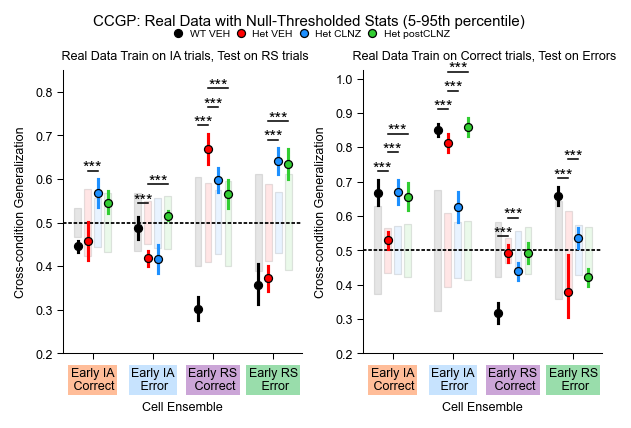

In [54]:
# --- CCGP: Real data with null-thresholded posthoc stats ---
fig, axes = plt.subplots(1, 2, figsize=(4, 2.5), layout="constrained")

# Figure 3B: Train on IA, Test on RS
train_data = "train_Early_IA_Correct_Early_IA_Error"
decode_comp_3b = "Early IA Correct Early IA Error v Early RS Correct Early RS Error"
ensembles_3b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_df_3b = plot_cross_condition_generalization_performance_w_null(
    axes[0], decode_out_distrib, decode_out_distrib_label_permuted,
    decoding_col="classes decoded", decode_comp=decode_comp_3b,
    enriched_group="enriched_group", ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85], verbose_titles=["Real Data", verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[0], ensembles_3b, stage_palette_dict)

# Figure 4B: Train on Correct, Test on Error
train_data = "train_Early_IA_Correct_Early_RS_Correct"
decode_comp_4b = "Early IA Correct Early RS Correct v Early IA Error Early RS Error"
ensembles_4b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_df_4b = plot_cross_condition_generalization_performance_w_null(
    axes[1], decode_out_distrib, decode_out_distrib_label_permuted,
    decoding_col="classes decoded", decode_comp=decode_comp_4b,
    enriched_group="enriched_group", ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025], verbose_titles=["Real Data", verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[1], ensembles_4b, stage_palette_dict)

# Clean up legends
for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()
hand, labs = axes[0].get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc="lower center", ncols=4, frameon=False)
fig.suptitle("CCGP: Real Data with Null-Thresholded Stats (5-95th percentile)", y=1.08)

## save fig:
combined_fig_name = "CCG_Real_vs_LabelPermuted_Overlay_NullThresholded"
save_fig_in_main_fig_dir(fig, fig_name=combined_fig_name, folder_key="s_2", filetypes_to_save=["png", "svg"])


#### Null band + % classification


In [55]:
# decode_CCG_whole_pop_permute = decode_dfs.get('decode_out_distrib_whole_pop_permuted')

# decode_CCG_whole_pop_permute['train_on'] = decode_CCG_whole_pop_permute['class_0_train'].str.cat(decode_CCG_whole_pop_permute['class_1_train'], sep = "_").str.replace('_', ' ')
# decode_CCG_whole_pop_permute['test_on'] = decode_CCG_whole_pop_permute['class_0_test'].str.cat(decode_CCG_whole_pop_permute['class_1_test'], sep = "_").str.replace('_', ' ')
# decode_CCG_whole_pop_permute['classes decoded'] = decode_CCG_whole_pop_permute['train_on'].str.cat(decode_CCG_whole_pop_permute['test_on'], sep = " v ")
# decode_CCG_whole_pop_permute['classes decoded'] = decode_CCG_whole_pop_permute['classes decoded'].str.replace('_', ' ')
# decode_CCG_whole_pop_permute['total'] = decode_CCG_whole_pop_permute['true_pos'] + decode_CCG_whole_pop_permute['false_neg'] + decode_CCG_whole_pop_permute['false_pos'] + decode_CCG_whole_pop_permute['true_neg']
# decode_CCG_whole_pop_permute.tail(3)

In [56]:
null_CCG_prediction = transform_confusion_cols(decoding_results=decode_out_distrib_label_permuted, confusion_mat_cols = confusion_mat_cols, run_ID_cols = run_ID_cols, class_list = class_list)
null_CCG_prediction.head()

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.519531,0,0.523750,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.602051,0,0.607500,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Early RS Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.491699,0,0.388125,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,Het CLNZ,0.494629,0,0.457500,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Early IA Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.530273,0,0.551250,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos


#### Figure 3C + Null

In [57]:
def add_null_bands_confusion(ax, null_proportion_df, train, ens, prediction_class,
                             genos_to_plot=geno_order, dodge=0.5):
    """Overlay shaded 5th-95th percentile null bands on a ccg confusion proportion plot."""
    marker_params = {True: geno_order_w_WT_CLNZ_no_eb, False: geno_color_dict_no_errorbar}["WT CLNZ" in genos_to_plot]
    hue_col = marker_params['hue']
    hue_order = marker_params['hue_order']
    palette = marker_params['palette']
    n_hue = len(hue_order)
    offsets = np.linspace(-dodge / 2, dodge / 2, n_hue)
    band_width = dodge / n_hue * 0.9

    # Filter null data the same way plot_ccg_confusion_single_proportion does
    plot_df = null_proportion_df.loc[train, :].reset_index()
    plot_df = plot_df.loc[(plot_df.ensemble == ens) & (plot_df.predict == prediction_class)]
    plot_df['value'] = plot_df['value'] * 100
    stage_order = sorted(set(plot_df['actual']))

    for stage_idx, stage in enumerate(stage_order):
        for hue_idx, geno in enumerate(hue_order):
            subset = plot_df.loc[(plot_df['actual'] == stage) & (plot_df[hue_col] == geno), 'value']
            if len(subset) == 0:
                continue
            p5, p95 = subset.quantile(0.05), subset.quantile(0.95)
            x_center = stage_idx + offsets[hue_idx]
            x_left, x_right = x_center - band_width / 2, x_center + band_width / 2
            color = palette[hue_idx]
            ax.fill_between([x_left, x_right], p5, p95,
                            color=color, alpha=0.1, zorder=0, linewidth=0)


Saved 3_null_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\3_null_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


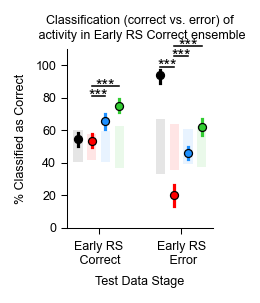

In [58]:
##Figure 3- TRAIN IA
ensemble = "Early_RS_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'tight')
posthoc_df = plot_ccg_confusion_single_proportion(ax, CCGP_prediction_df,
                                                  train = 'train_Early_IA_Correct_x_Early_IA_Error',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order,
                                                  prediction_class= "Predict_Early_IA_Correct",
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 110],)

add_null_bands_confusion(ax, null_CCG_prediction,
                         train='train_Early_IA_Correct_x_Early_IA_Error',
                         ens=ensemble, prediction_class="Predict_Early_IA_Correct",
                         genos_to_plot=geno_order)
##savefig 
fig_num = 3
fig_name = f"null_CCG single class pred- Train IA test RS - {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix= "predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Figure 4C + Null: % samples classified as RS, for activity from Early IA Correct ensemble

Saved 4_null_  CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_null_  CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


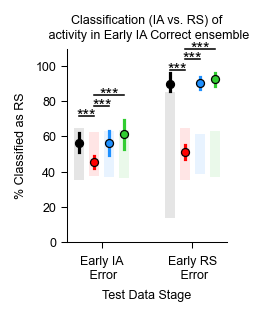

In [59]:
ensemble = "Early_IA_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, CCGP_prediction_df,
                                       train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                       ens= ensemble,
                                       genos_to_plot = geno_order,
                                       prediction_class = "Predict_Early_RS_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 110])

add_null_bands_confusion(ax, null_CCG_prediction,
                         train='train_Early_IA_Correct_x_Early_RS_Correct',
                         ens=ensemble, prediction_class="Predict_Early_RS_Correct",
                         genos_to_plot=geno_order)
##savefig 
fig_num = 4
fig_name = f"null_  CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None,
                        csv_suffix="predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Figure 4F + Null: % of samples classified as RS, for activity from Early RS Error ensemble

Saved 4_null_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d_05_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_null_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d text_05_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


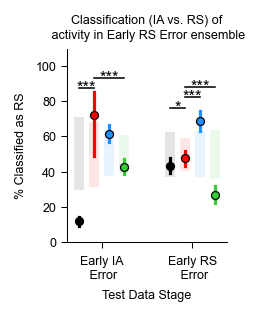

In [60]:
ensemble = "Early_RS_Error"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax,CCGP_prediction_df,
                                                  train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order ,
                                                  prediction_class= "Predict_Early_RS_Correct",
                                                  errorbar = ('pi', 75),    
                                                  ylim=[0, 110],)
add_null_bands_confusion(ax, null_CCG_prediction,
                         train='train_Early_IA_Correct_x_Early_RS_Correct',
                         ens=ensemble, prediction_class="Predict_Early_RS_Correct",
                         genos_to_plot=geno_order)
##savefig 
fig_num = 4
fig_name = f"null_CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix="predict_posthoc cohen d",txt_suffix="predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Combined CCG Predictions + Null: 3C, 4C & F

In [61]:
def plot_ccg_confusion_single_proportion_w_null(ax,
                                         proportion_df,
                                         null_proportion_df,
                                         train,
                                         ens,
                                         prediction_class = "Predict_Early_RS_Correct",
                                         genos_to_plot = geno_order,
                                         errorbar = ("pi", 95),
                                         ylim=[0, 0.515],
                                         title_type = {"train_Early_IA_Correct_x_Early_RS_Correct":"Classification (IA vs. RS) of \n",
                                                       "train_Early_IA_Correct_x_Early_IA_Error": "Classification (correct vs. error) of \n"},
                                         null_percentiles = (0.05, 0.95),
                                         **kwargs):
    """Plot ccg confusion proportions with null bands, only running posthoc stats
    for comparisons where at least 1 group's median exceeds the null distribution at that stage."""
    # Filter and prep real data
    proportion_df = proportion_df.loc[train,:].reset_index()
    plot_df = proportion_df.loc[proportion_df.ensemble == ens,:].copy()
    plot_df.loc[:,"actual"] = plot_df.loc[:,"actual"].str.removeprefix("Actual_").str.replace("_", " ")
    plot_df = plot_df.loc[plot_df.predict == prediction_class,:]
    plot_df["value"] = plot_df["value"] * 100
    stage_order = sorted(set(plot_df.loc[:,"actual"]))
    
    marker_params = {True:geno_order_w_WT_CLNZ_no_eb, False:geno_color_dict_no_errorbar}["WT CLNZ" in genos_to_plot]
    plot_params = dict(data=plot_df, ax=ax, x="actual", y="value", dodge=0.5,
                       linestyles="none", order=stage_order, errorbar=errorbar, **marker_params)
    s = sns.pointplot(**plot_params)
    set_pointplot_edgecolor(ax)
    
    # Ax decorators
    ax_title = f"{title_type[train]} activity in {ens.replace("_", " ")} ensemble"
    ylabel_options = {"train_Early_IA_Correct_x_Early_IA_Error": "Correct",
                      "train_Early_IA_Correct_x_Early_RS_Correct": "RS"}
    set_labels(ax, label_dict={"title": ax_title, "legend_false": True,
                               "xlabel": "Test Data Stage", "ylim": ylim,
                               "ylabel": f"% Classified as {ylabel_options[train]}"})
    
    # Prep null data for filtering
    hue_col = marker_params["hue"]
    null_df = null_proportion_df.loc[train,:].reset_index()
    null_df = null_df.loc[(null_df.ensemble == ens) & (null_df.predict == prediction_class)]
    null_df["value"] = null_df["value"] * 100
    
    if "WT CLNZ" in marker_params["hue_order"]:
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    
    # Run posthoc tests on all comparisons
    ax.figure.canvas.draw()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, s, comparisons,
                                                            detect_error_bar=True, test_name="cohen_d")
    
    # Per-stage null filtering: keep a posthoc row only if at least 1 group's
    # median exceeds the null 5th/95th percentile at that specific stage
    rows_to_keep = []
    for idx, row in posthoc_df.iterrows():
        stage = row["category_compared_within"]
        exceeds_null = False
        for geno in [row["group_1"], row["group_2"]]:
            real_vals = plot_df.loc[(plot_df["actual"] == stage) & (plot_df[hue_col] == geno), "value"]
            null_vals = null_df.loc[(null_df["actual"] == stage) & (null_df[hue_col] == geno), "value"]
            if len(real_vals) == 0 or len(null_vals) == 0:
                continue
            p_low = null_vals.quantile(null_percentiles[0])
            p_high = null_vals.quantile(null_percentiles[1])
            if real_vals.median() > p_high or real_vals.median() < p_low:
                exceeds_null = True
                break
        rows_to_keep.append(exceeds_null)
    
    null_mask = pd.Series(rows_to_keep, index=posthoc_df.index)
    posthoc_sig = posthoc_df.loc[null_mask & (posthoc_df["pvalue"] < 0.05)]
    print(f"Posthoc: {len(posthoc_df)} total, {null_mask.sum()} exceed null, {len(posthoc_sig)} plotted")
    if len(posthoc_sig) > 0:
        plot_sig_bars_w_comp_df_tight(ax, posthoc_sig,
                                      tight_offset=0.0175, offset_constant=0.0085)
    
    # Add null bands AFTER posthoc tests (avoid polluting ax.collections)
    add_null_bands_confusion(ax, null_proportion_df, train, ens, prediction_class,
                             genos_to_plot=genos_to_plot)
    
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels()))
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 100])
    return posthoc_df

Posthoc: 6 total, 5 exceed null, 5 plotted
Posthoc: 6 total, 3 exceed null, 3 plotted
Posthoc: 6 total, 5 exceed null, 4 plotted
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\05_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\05_Mar_2026' already exists.


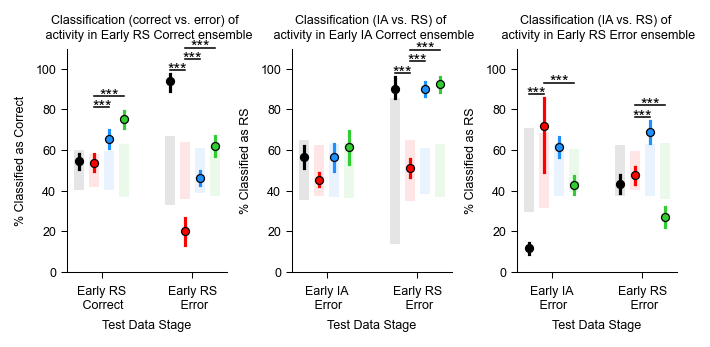

In [62]:
## Combined CCG Predictions + Null: 3C, 4C, 4F
plot_configs = [
    {"ensemble": "Early_RS_Correct",
     "train": "train_Early_IA_Correct_x_Early_IA_Error",
     "prediction_class": "Predict_Early_IA_Correct",
     "title_label": "3C"},
    {"ensemble": "Early_IA_Correct",
     "train": "train_Early_IA_Correct_x_Early_RS_Correct",
     "prediction_class": "Predict_Early_RS_Correct",
     "title_label": "4C"},
    {"ensemble": "Early_RS_Error",
     "train": "train_Early_IA_Correct_x_Early_RS_Correct",
     "prediction_class": "Predict_Early_RS_Correct",
     "title_label": "4F"},
]

fig, axes = plt.subplots(1, 3, figsize=(ccg_uniprop_figsize[0] * 3, 1.1* ccg_uniprop_figsize[1]), layout="constrained")

for ax, config in zip(axes, plot_configs):
    plot_ccg_confusion_single_proportion_w_null(ax, CCGP_prediction_df, null_CCG_prediction,
                                         train=config["train"],
                                         ens=config["ensemble"],
                                         prediction_class=config["prediction_class"],
                                         genos_to_plot=geno_order,
                                         errorbar=('pi', 75),
                                         ylim=[0, 110])
    # posthoc_df = plot_ccg_confusion_single_proportion(ax, CCGP_prediction_df,
    #                                                   train=config["train"],
    #                                                   ens=config["ensemble"],
    #                                                   genos_to_plot=geno_order,
    #                                                   prediction_class=config["prediction_class"],
    #                                                   errorbar=("pi", 75),
    #                                                   ylim=[0, 110])
    # add_null_bands_confusion(ax, null_CCG_prediction,
    #                          train=config["train"],
    #                          ens=config["ensemble"],
    #                          prediction_class=config["prediction_class"],
    #                          genos_to_plot=geno_order)

## savefig
fig_name = "Combined CCG single class pred + Null - 3C 4C 4F"
save_fig_in_main_fig_dir(fig, fig_name=fig_name, folder_key="s_2", filetypes_to_save=["png", "svg"])
